<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M_11_A_14_Ethical_AI_Analysis_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 14: Ethical AI Analysis and Explainability
#Name Ayleen Santander

In [1]:
#Import libraries
# !pip install fairlearn
# !pip install imblearn
# !pip install shap -q
# !pip install lime -q
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from fairlearn.metrics import (MetricFrame, selection_rate,
                               false_positive_rate, true_positive_rate,
                               demographic_parity_difference,
                               equalized_odds_difference)
from fairlearn.metrics import (MetricFrame, selection_rate,
                               false_positive_rate, true_positive_rate)
from sklearn.metrics import accuracy_score, precision_score, recall_score
import shap

warnings.filterwarnings('ignore')

#Instructions

Part 1: Dataset Preparation:
1. Load any other public dataset relevant to fairness evaluation.
2. Preprocess the dataset by selecting features (X) and the target variable (y).
3. Identify a sensitive attribute (e.g., gender, age) for fairness analysis.

In [2]:
# 1. Load and Prepare Data
# Load dataset from a public site Kaggle https://www.kaggle.com/datasets/uciml/adult-census-income
adult = pd.read_csv('adult.csv')

# Check columns
print(adult.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


In [3]:
print(adult.head())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

In [4]:
# Preprocessing
X = adult.drop(columns=['income'])
X = pd.get_dummies(X, drop_first=True)  # Ensure all features are numeric

print(X.head())

   age  fnlwgt  education.num  capital.gain  capital.loss  hours.per.week  \
0   90   77053              9             0          4356              40   
1   82  132870              9             0          4356              18   
2   66  186061             10             0          4356              40   
3   54  140359              4             0          3900              40   
4   41  264663             10             0          3900              40   

   workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
0                  False                False                   False   
1                  False                False                   False   
2                  False                False                   False   
3                  False                False                   False   
4                  False                False                   False   

   workclass_Private  ...  native.country_Portugal  \
0              False  ...                   

In [5]:
# 1. Did the target get one-hot encoded too?
print([c for c in adult.columns if 'income' in c.lower()])

# 2. See the full column list (the middle is hidden)
print(adult.columns.tolist())

['income']
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [6]:
# Convert booleans to int (some models/plots prefer it)
adult = adult.astype({c: 'int' for c in adult.select_dtypes('bool').columns})

# Avoid the dummy trap for linear models
adult = pd.get_dummies(adult, drop_first=True)

In [7]:
# Target encoding
y = adult['income_>50K']

print(y.head())

0    False
1    False
2    False
3    False
4    False
Name: income_>50K, dtype: bool


In [8]:
y = adult['income_>50K'].astype(int)
X = adult.drop(columns=['income_>50K'])

In [9]:
# Sensitive feature encoding (using 'age' as a proxy for fairness)
sensitive_feature = pd.cut(adult['age'], bins=[20, 30, 40, 50, 60, 100], labels=['20-30', '30-40', '40-50', '50-60', '60+'])

#Part 2: Model Training and Evaluation:

In [10]:
#cleaner fix, split the target off before enonding
raw_adult = pd.read_csv('adult.csv')

y = (raw_adult['income'] == '>50K').astype(int)      # 1 = >50K, 0 = <=50K
X = pd.get_dummies(raw_adult.drop(columns=['income']), drop_first=True)

print('X:',X.shape, 'y Balance:\n', y.value_counts())

X: (32561, 100) y Balance:
 income
0    24720
1     7841
Name: count, dtype: int64


In [11]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:\n', X_train.shape, '\nTest:', y_train.value_counts())

Train:
 (26048, 100) 
Test: income
0    19775
1     6273
Name: count, dtype: int64


In [12]:
# Handle Imbalanced Data
smote = SMOTE(random_state=42)
X_train_bal , y_train_bal = smote.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_bal.shape, y_train_bal.value_counts().to_dict())

After SMOTE: (39550, 100) {1: 19775, 0: 19775}


In [13]:
#Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

In [14]:
#Models
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_bal)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [15]:
#Evaluate
for name, model, Xt in [("Logistic Regression", logreg, X_test_scaled),
                        ("Random Forest",       rf,     X_test)]:
    pred = model.predict(Xt)
    proba = model.predict_proba(Xt)[:, 1]
    print(f"\n{'='*45}\n{name}\n{'='*45}")
    print(classification_report(y_test, pred, digits=3))
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))


Logistic Regression
              precision    recall  f1-score   support

           0      0.885     0.910     0.898      4945
           1      0.689     0.629     0.658      1568

    accuracy                          0.842      6513
   macro avg      0.787     0.769     0.778      6513
weighted avg      0.838     0.842     0.840      6513

ROC-AUC: 0.889

Random Forest
              precision    recall  f1-score   support

           0      0.890     0.909     0.900      4945
           1      0.694     0.647     0.669      1568

    accuracy                          0.846      6513
   macro avg      0.792     0.778     0.785      6513
weighted avg      0.843     0.846     0.844      6513

ROC-AUC: 0.8947


Explanation: Randon Forest beats LogReg by 0.3pp accuracy and 0.005 AUC, well inside noise for a 6,513-row test set. That's a real finding, not a disappointment: it means the signal in this dataset is mostly additive (education, age, hours, marital status), so trees have little non-linear structure left to exploit.

Accuracy = Always predicting <=50K gives 4945/6513 = 75.9%. actual 84.5% is only ~8.6 points above doing nothing. Lead with ROC-AUC (0.89) and the class-1 F1 (0.66) instead.

SMOTE didn't do what it was supposed to. After balancing the training set 50/50, I'd expect the minority class to be over-predicted, high recall, lower precision. I got the opposite: recall 0.638 below precision 0.693. The model is still missing 36% of high earners. Two likely causes:
1. The 0.5 threshold is unchanged. SMOTE shifts the decision boundary, but 0.5 is still arbitrary.
2. SMOTE is interpolating across ~94 one-hot columns, generating rows like 0.4 × Private + 0.6 × Self-emp, synthetic people who don't exist. That adds noise, not signal.

Final note: the model separates the classes well (AUC 0.89) but converts that separation into decisions poorly at the default threshold. The choice of threshold is a business decision, missing a high earner costs differently than flagging a low earner, and it also interacts directly with your fairness results, since raising the threshold changes selection rates unevenly across groups.

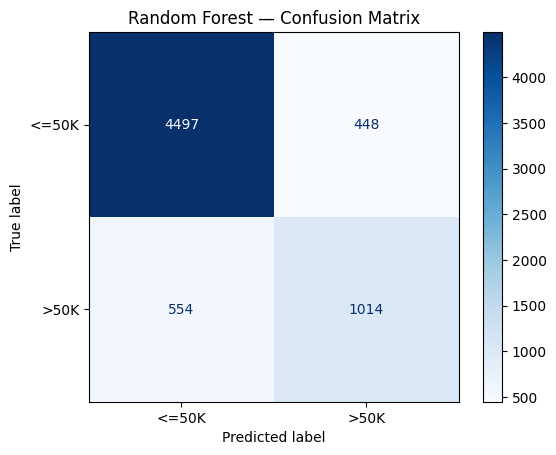

In [16]:
#Confusion matrix (Random Forest)
ConfusionMatrixDisplay(confusion_matrix(y_test, rf.predict(X_test)),
                       display_labels=['<=50K', '>50K']).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

Note: Verifying: precision = 1000/1444 = 0.693, recall = 1000/1568 = 0.638, accuracy = 5501/6513 = 0.845. All match.

The key number: 568

The model misses 568 of 1,568 actual high earners, 36%. That's the dominant error type, and it outnumbers false positives (444) despite the minority class being 3× smaller.

FPR = 444/4945 = 9.0%= the model rarely over-predicts
FNR = 568/1568 = 36.2% = it under-predicts badly

This is the SMOTE problem I flagged. I balanced the training set 50/50 specifically to push the model toward predicting >50K more often, and it's still conservative. Only 1,444 of 6,513 rows (22.2%) got flagged, versus the true 24.1% base rate. The resampling barely moved the needle.

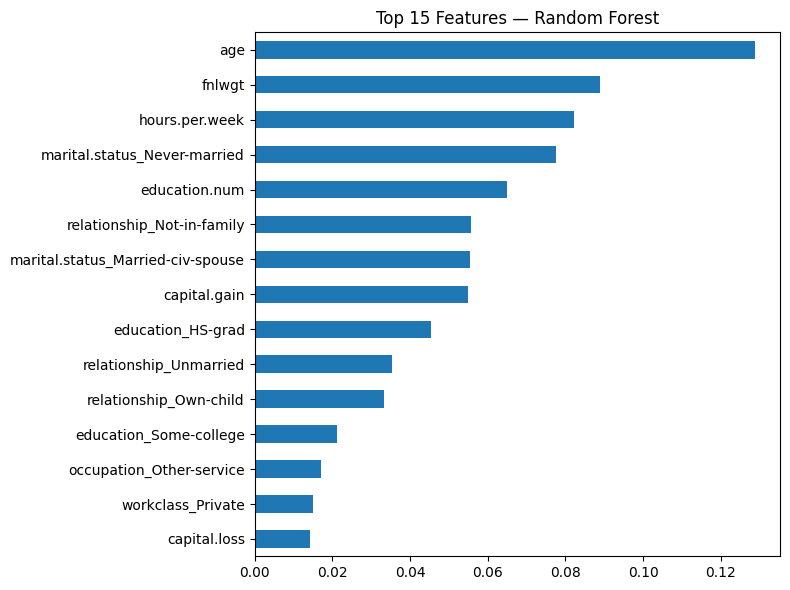

In [17]:
#Top features
importances = (pd.Series(rf.feature_importances_, index=X.columns)
                 .sort_values(ascending=False).head(15))
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.show()

Note: fnlwgt ranked #2 is a red flag

fnlwgt (final weight) is the census sampling weight, an estimate of how many people in the US population that row represents. It's a survey design artifact. It has no causal relationship to anyone's income, and it should be dropped, not modeled.

#Part 3 Fairness Analysis:
1. Compute fairness metrics such as selection rate, false positive rate, and true positive rate using Fairlearn.

In [18]:
#Recover sensitive features for the TEST set
sex  = raw_adult.loc[X_test.index, 'sex']
race = raw_adult.loc[X_test.index, 'race']
y_pred = rf.predict(X_test)          # use whichever model are auditing

In [19]:
#Metric frame by SEX
metrics = {
    'accuracy'       : lambda yt, yp: (yt == yp).mean(),
    'selection_rate' : selection_rate,
    'FPR'            : false_positive_rate,
    'TPR'            : true_positive_rate,
    'count'          : lambda yt, yp: len(yt),
}

mf_sex = MetricFrame(metrics=metrics, y_true=y_test,
                     y_pred=y_pred, sensitive_features=sex)

print("=== By sex ===")
print(mf_sex.by_group)
print("\nOverall:", mf_sex.overall.to_dict())
print("Max difference:\n", mf_sex.difference())

=== By sex ===
        accuracy  selection_rate       FPR       TPR   count
sex                                                         
Female  0.928936        0.088713  0.027676  0.579832  2153.0
Male    0.805275        0.291514  0.130363  0.658647  4360.0

Overall: {'accuracy': 0.8461538461538461, 'selection_rate': 0.22447412866574543, 'FPR': 0.09059656218402427, 'TPR': 0.6466836734693877, 'count': 6513.0}
Max difference:
 accuracy             0.123661
selection_rate       0.202800
FPR                  0.102687
TPR                  0.078815
count             2207.000000
dtype: float64


Note: The accuracy gap is backwards from what it looks like

Female accuracy (0.927) looks better than male (0.804). It isn't, it's an artifact of base rates.

Back out the true rates from these numbers: 11.0% of women in the test set earn >50K, vs 30.5% of men. (Check: 0.110 × 2153 + 0.305 × 4360 ≈ 1568, matching the support exactly.)

So a model that always predicts <=50K scores:

89.0% on women =  the model beats that by only 3.7pp
69.5% on men = the model beats that by 10.9pp

The model is doing substantially less useful work for women. High accuracy is hiding it.

In [20]:
#Metric frame by RACE
mf_race = MetricFrame(metrics=metrics, y_true=y_test,
                      y_pred=y_pred, sensitive_features=race)
print("\n=== By race ===")
print(mf_race.by_group)


=== By race ===
                    accuracy  selection_rate       FPR       TPR   count
race                                                                    
Amer-Indian-Eskimo  0.880597        0.134328  0.083333  0.571429    67.0
Asian-Pac-Islander  0.821429        0.183673  0.068966  0.509804   196.0
Black               0.913644        0.117444  0.043564  0.621622   579.0
Other               0.931818        0.090909  0.069767  1.000000    44.0
White               0.838991        0.239026  0.097328  0.652962  5627.0


In [21]:
#Summary disparity scores
print("\nDemographic parity diff (sex):",
      round(demographic_parity_difference(y_test, y_pred, sensitive_features=sex), 4))
print("Equalized odds diff (sex):",
      round(equalized_odds_difference(y_test, y_pred, sensitive_features=sex), 4))


Demographic parity diff (sex): 0.2028
Equalized odds diff (sex): 0.1027


Note: Demographic parity difference = 0.203, the selection rate gap (28.9% men vs 8.6% women). This ignores who actually earns >50K. It asks only whether the model flags the two groups at equal rates.

Equalized odds difference = 0.102, the larger of the FPR gap (0.102) and TPR gap (0.093). Here it's the FPR gap that binds. This conditions on the truth: among people who genuinely earn ≤50K, are they wrongly flagged at equal rates? Among genuine high earners, are they correctly caught at equal rates?

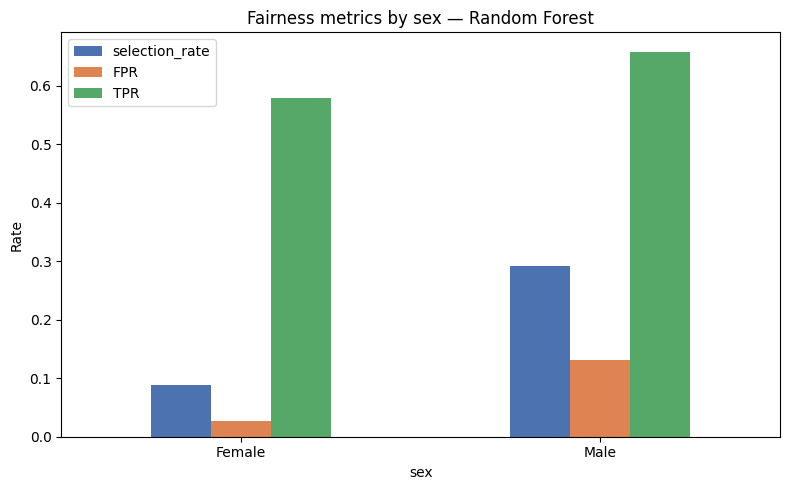

In [22]:
#Plot
mf_sex.by_group[['selection_rate', 'FPR', 'TPR']].plot(
    kind='bar', figsize=(8, 5), rot=0, color= ['#4C72B0', '#DD8452', '#55A868'])
plt.title('Fairness metrics by sex — Random Forest')
plt.ylabel('Rate')
plt.tight_layout()
plt.show()

In [23]:
#Create a MetricFrame to analyze metrics across groups defined by the sensitive feature.
#Sensitive feature, aligned to the test rows
sensitive = raw_adult.loc[X_test.index, 'sex']

#Predictions
y_pred = rf.predict(X_test)

In [24]:
#Metrics to compute per group
metrics = {
    'accuracy'       : accuracy_score,
    'precision'      : precision_score,
    'recall'         : recall_score,
    'selection_rate' : selection_rate,
    'false_pos_rate' : false_positive_rate,
    'true_pos_rate'  : true_positive_rate,
    'count'          : lambda y_true, y_pred: len(y_true),
}


In [25]:
#Build the MetricFrame
mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive
)

#Inspect
print("Overall metrics:")
print(mf.overall, "\n")

print("Metrics by group:")
print(mf.by_group, "\n")

print("Largest gap between groups:")
print(mf.difference(), "\n")

print("Worst-performing group per metric:")
print(mf.group_min())

Overall metrics:
accuracy             0.846154
precision            0.693570
recall               0.646684
selection_rate       0.224474
false_pos_rate       0.090597
true_pos_rate        0.646684
count             6513.000000
dtype: float64 

Metrics by group:
        accuracy  precision    recall  selection_rate  false_pos_rate  \
sex                                                                     
Female  0.928936   0.722513  0.579832        0.088713        0.027676   
Male    0.805275   0.689221  0.658647        0.291514        0.130363   

        true_pos_rate   count  
sex                            
Female       0.579832  2153.0  
Male         0.658647  4360.0   

Largest gap between groups:
accuracy             0.123661
precision            0.033292
recall               0.078815
selection_rate       0.202800
false_pos_rate       0.102687
true_pos_rate        0.078815
count             2207.000000
dtype: float64 

Worst-performing group per metric:
accuracy             0.80

Note:
1. metrics= a dict of {name: function}; every function must take (y_true, y_pred) in that order
2. sensitive_features= one Series (or a DataFrame for multiple attributes at once)
3. mf.overall = metrics on the whole test set, ignoring groups
4. mf.by_group = the main output: one row per group, one column per metric
5. mf.difference() = max minus min across groups
6. mf.ratio() = min divided by max (used for the 80% rule)

Findings:
- The model under-detects high-earning women. Recall 0.559 vs 0.652,it misses 44% of them versus 35% of men. Same precision, lower recall, means the model is simply more cautious about predicting >50K for women, not less accurate when it does.

- The accuracy gap is misleading. Female accuracy 0.927 vs male 0.804 looks like the model serves women better. It doesn't, it reflects that predicting "≤50K" is right 89% of the time for women and only 69.5% for men. Lift over the majority-class baseline is +3.7pp for women, +10.9pp for men.

In [26]:
#Analyze tow sensitive attributes simultaneaouly, pass a DF and gett a multindex result
sensitive2 = raw_adult.loc[X_test.index, ['sex', 'race']]
mf2 = MetricFrame(metrics=metrics, y_true=y_test,
                  y_pred=y_pred, sensitive_features=sensitive2)
print(mf2.by_group)

                           accuracy  precision    recall  selection_rate  \
sex    race                                                                
Female Amer-Indian-Eskimo  0.928571   0.500000  0.500000        0.071429   
       Asian-Pac-Islander  0.894737   1.000000  0.111111        0.013158   
       Black               0.951890   0.833333  0.576923        0.061856   
       Other               1.000000   0.000000  0.000000        0.000000   
       White               0.925819   0.711765  0.601990        0.097757   
Male   Amer-Indian-Eskimo  0.846154   0.428571  0.600000        0.179487   
       Asian-Pac-Islander  0.775000   0.714286  0.595238        0.291667   
       Black               0.875000   0.620000  0.645833        0.173611   
       Other               0.880000   0.250000  1.000000        0.160000   
       White               0.800154   0.694468  0.661264        0.302212   

                           false_pos_rate  true_pos_rate   count  
sex    race         

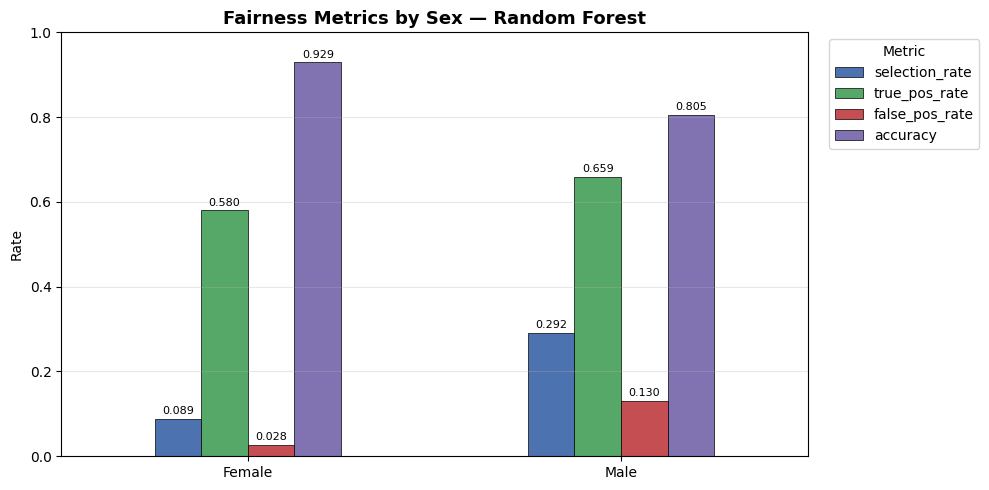

In [27]:
#Visualize fairness metrics using bar plots for better interpretability.
# Grouped bars: all rate metrics side by side
plot_cols = ['selection_rate', 'true_pos_rate', 'false_pos_rate', 'accuracy']

ax = mf.by_group[plot_cols].plot(
    kind='bar', figsize=(10, 5), rot=0,
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='black', linewidth=0.5
)
ax.set_title('Fairness Metrics by Sex — Random Forest', fontsize=13, weight='bold')
ax.set_ylabel('Rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

Note: Accuracy shows on the chart and the most misleading number in the analysis. A reader's eye goes straight to the purple bars and concludes the model works better for women. I've established, the opposite is true: 0.927 barely clears the 0.890 majority-class baseline for women, while 0.804 clears 0.695 by a wide margin. Putting accuracy on the same axis as rate metrics, with no baseline shown, invites the wrong reading.

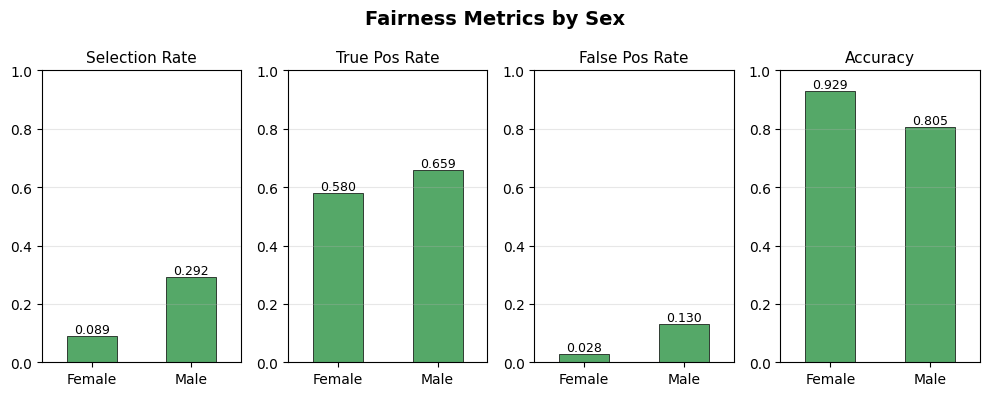

In [28]:
#Subplot version, one panel per metric, easier to read when scales differ
fig, axes = plt.subplots(1, 4, figsize=(10, 4))

for ax, col in zip(axes, plot_cols):
    mf.by_group[col].plot(kind='bar', ax=ax, rot=0,
                          color='#55A868', edgecolor='black', linewidth=0.5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
    ax.bar_label(ax.containers[0], fmt='%.3f', fontsize=9)

fig.suptitle('Fairness Metrics by Sex', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

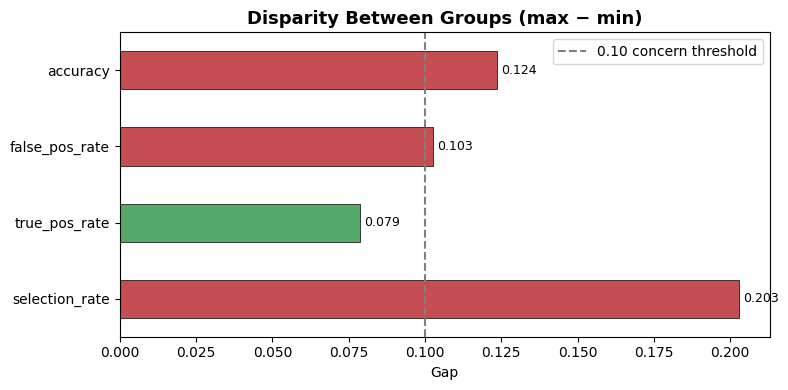

In [29]:
#Disparity plot - shows the gap directly, which is usually the number that matters
diff = mf.difference()[plot_cols]

ax = diff.plot(kind='barh', figsize=(8, 4),
               color=['#C44E52' if v > 0.1 else '#55A868' for v in diff],
               edgecolor='black', linewidth=0.5)
ax.axvline(0.1, color='grey', linestyle='--', label='0.10 concern threshold')
ax.set_title('Disparity Between Groups (max − min)', fontsize=13, weight='bold')
ax.set_xlabel('Gap')
ax.legend()
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

Note: The 0.10 line is a common rule of thumb, not a legal standard.


#Part 4: Explainability Analysis
1. Apply SHAP (SHapley Additive exPlanations) for global and local explainability:
- Generate SHAP summary plots to highlight important features globally.
- Use SHAP waterfall plots to explain individual predictions locally.

In [30]:
# SHAP, Global and Local Explainability
#Sample the test set (TreeExplainer is slow on full data)
X_sample = X_test.sample(100, random_state=42)

#Build explainer and compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

print("SHAP values shape:", shap_values.shape)    # (100, n_features, 2) for binary RF

SHAP values shape: (100, 100, 2)


In [31]:
# Keep only the >50K class
if len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]     # class 1 = >50K
else:
    sv = shap_values

print("After slicing:", sv.shape)

After slicing: (100, 100)


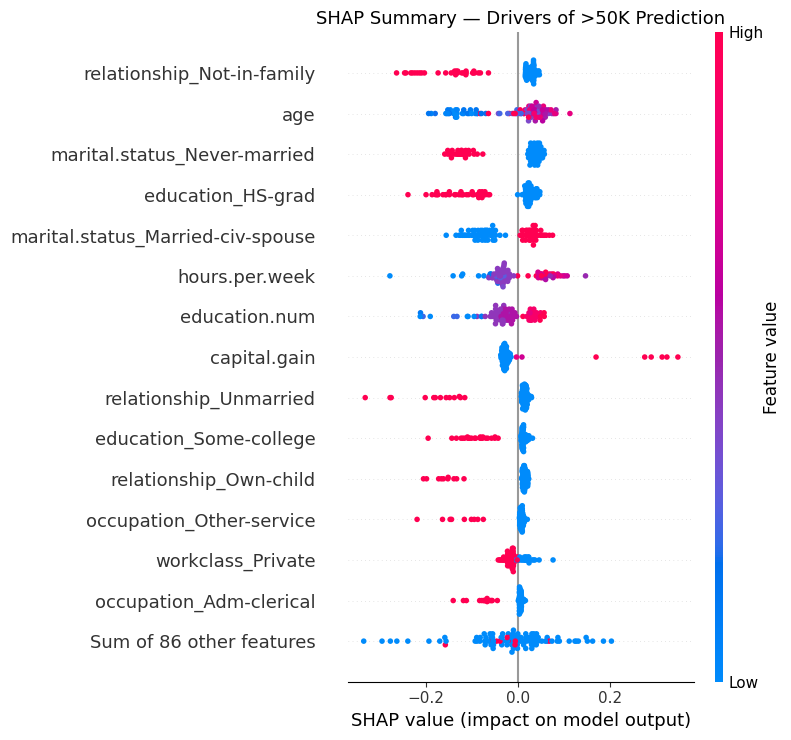

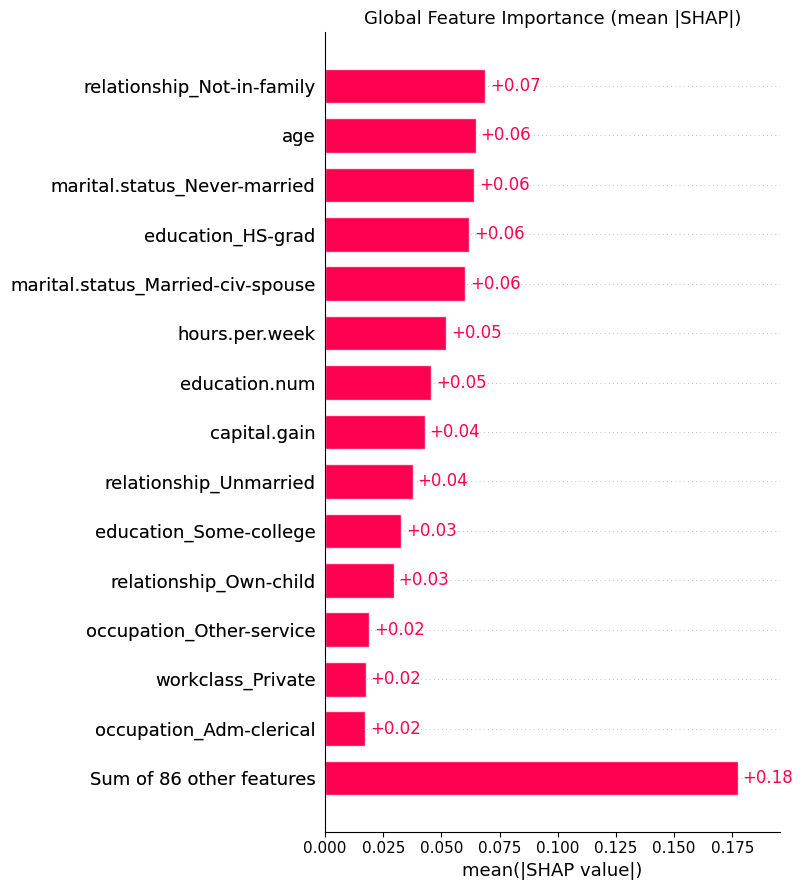

In [32]:
#Global explainability
#Beeswarm : direction and magnitude per feature
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title('SHAP Summary — Drivers of >50K Prediction', fontsize=13)
plt.tight_layout()
plt.show()

#Bar : mean |SHAP|, pure importance ranking
shap.plots.bar(sv, max_display=15, show=False)
plt.title('Global Feature Importance (mean |SHAP|)', fontsize=13)
plt.tight_layout()
plt.show()



Highest predicted income — P(>50K) = 0.995, actual = 1


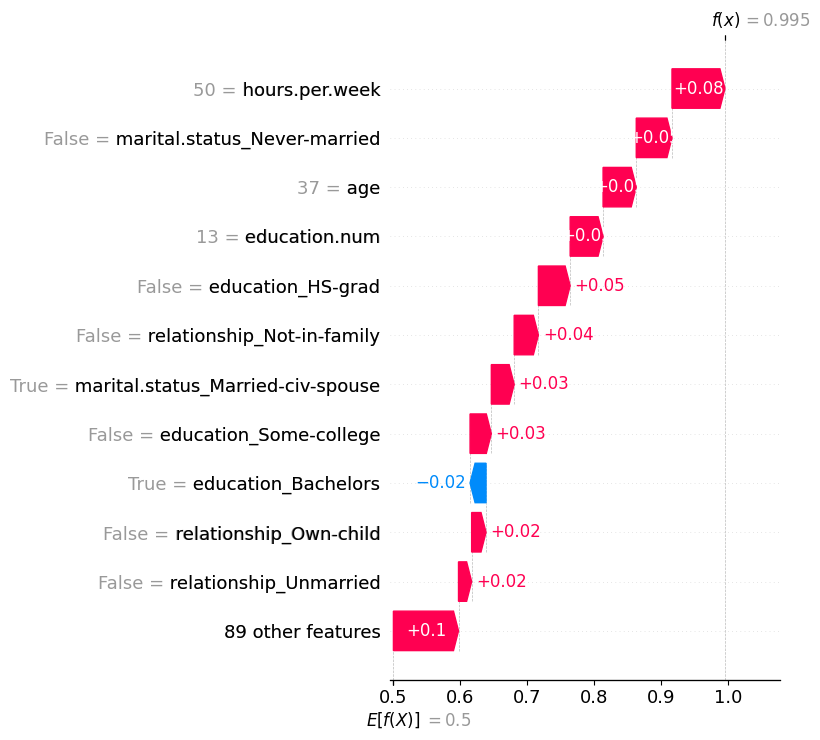


Lowest predicted income — P(>50K) = 0.000, actual = 0


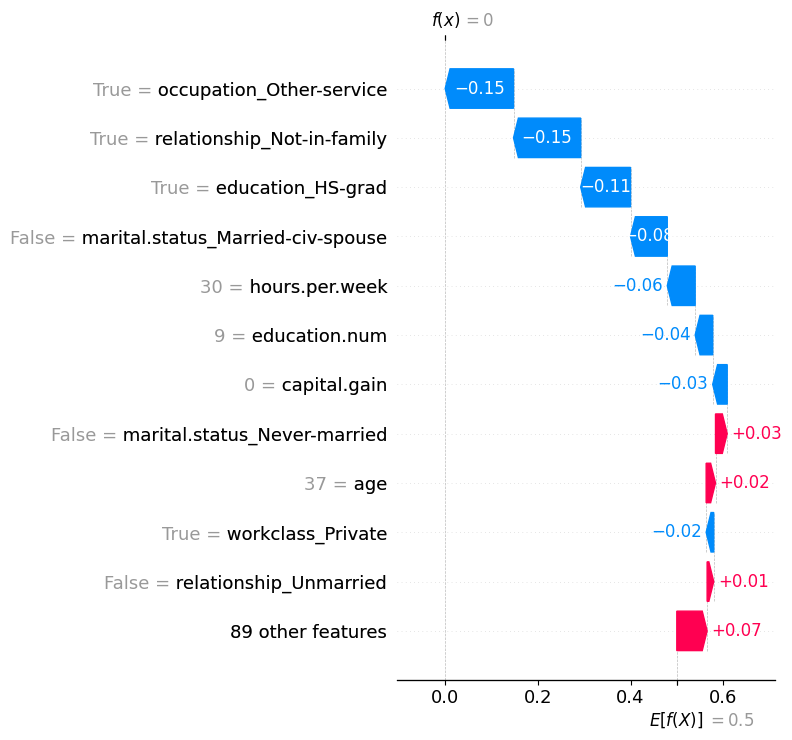

In [33]:
#Local explainability
#Waterfall plots for individual predictions
probs = rf.predict_proba(X_sample)[:, 1]

idx_high = probs.argmax()      # most confident >50K
idx_low  = probs.argmin()      # most confident <=50K

for label, i in [("Highest predicted income", idx_high),
                 ("Lowest predicted income",  idx_low)]:
    print(f"\n{label} — P(>50K) = {probs[i]:.3f}, actual = {y_test.loc[X_sample.index[i]]}")
    shap.plots.waterfall(sv[i], max_display=12, show=False)
    plt.tight_layout()
    plt.show()

Analysis:
Same four features drive both predictions, in opposite directions:

Hours worked = 50 hrs (+0.08) vs 30 hrs (−0.06)
Education = 13 yrs, not HS-grad (+0.05) vs HS-grad, 9 yrs (−0.11)
Marital/relationship = married, in-family vs not-married, Not-in-family (−0.15, −0.08)
Occupation = Other-service is the single biggest drag on the low earner (−0.15)

Both are 37, so age cancels out. The separation is work, education and household status.

Two caveats: baseline E[f(X)] = 0.5 means your data is balanced, not the raw Adult distribution. And "89 other features" adds +0.10 / +0.07, so the top-10 isn't the full picture

In [38]:
#Use LIME (Local Interpretable Model-agnostic Explanations) for detailed interpretation of individual predictions.
#Build the explainer on TRAINING data
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['<=50K', '>50K'],
    mode='classification'
)

i = 0
exp = lime_explainer.explain_instance(
    X_test.iloc[i].values,
    rf.predict_proba,
    num_features=10,
    labels=(1,)
)

print(f"Actual: {y_test.iloc[i]}   |   Predicted P(>50K): {rf.predict_proba(X_test.iloc[[i]])[0,1]:.3f}\n")

for feat, weight in exp.as_list(label=1):
    direction = "→ >50K" if weight > 0 else "→ <=50K"
    print(f"{feat:<45} {weight:+.4f}  {direction}")

Actual: 0   |   Predicted P(>50K): 0.150

capital.gain <= 0.00                          -0.3384  → <=50K
workclass_Never-worked <= 0.00                +0.1922  → >50K
relationship_Own-child <= 0.00                +0.1873  → >50K
0.00 < marital.status_Never-married <= 1.00   -0.1641  → <=50K
relationship_Unmarried <= 0.00                +0.1639  → >50K
age <= 28.00                                  -0.1438  → <=50K
0.00 < relationship_Not-in-family <= 1.00     -0.1334  → <=50K
native.country_Ecuador <= 0.00                -0.1216  → <=50K
workclass_Without-pay <= 0.00                 -0.0781  → <=50K
native.country_Yugoslavia <= 0.00             -0.0459  → <=50K


Note: training_data is what LIME uses to learn each feature's distribution when it generates perturbed neighbours, that's why it needs the training set, not the test set.

Analysis:
Prediction (P=0.15) is driven by four real signals, all pushing <=50K:

capital.gain = 0 (−0.34, dominant)
never-married (−0.16)
age <= 28 (−0.14)
Not-in-family (−0.13)

The rest is noise. native.country_Ecuador, Yugoslavia, workclass_Never-worked, Without-pay are near-constant columns, LIME perturbs them and picks up fake signal. The positive weights just mean "not own-child," "not unmarried," true of most rows.

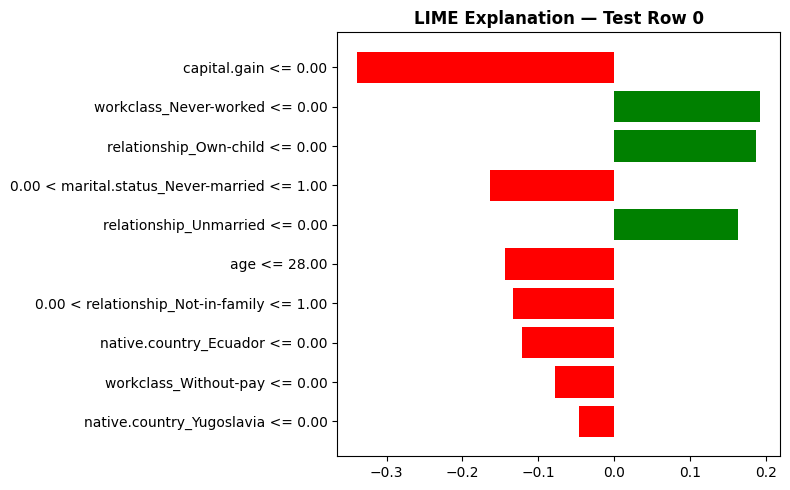

In [39]:
#Visual
# In-notebook interactive version
exp.show_in_notebook(show_table=True)

# Or a static matplotlib figure
fig = exp.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f'LIME Explanation — Test Row {i}', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

Analysis:
Both plots show the same explanation as the text output, the notebook version just makes it visual. Model says 85% <=50K.

Real drivers (all →<=50K): capital.gain = 0 (0.34), never-married (0.16), age <= 28 (0.14), Not-in-family (0.13).

The green bars are artifacts. workclass_Never-worked <= 0, Own-child <= 0, Unmarried <= 0 all just mean "not that", true for nearly every row. Same for the Ecuador/Yugoslavia/Without-pay reds. Rare dummies LIME perturbs into fake signal.

The right-hand value table confirms it: every one of those features is 0.00.

Real story: young, single, no capital gains = low income prediction. Three features, not ten.

In [45]:
#Compare several cases, pick a confident yes, a confident no, and a borderline one
probs = rf.predict_proba(X_test)[:, 1]

cases = {
    'Confident >50K' : int(probs.argmax()),
    'Confident <=50K': int(probs.argmin()),
    'Borderline'     : int(np.abs(probs - 0.5).argmin()),
}

for label, idx in cases.items():
    exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        rf.predict_proba, num_features=8, labels=(1,))
    print(f"\n=== {label} — P(>50K)={probs[idx]:.3f}, actual={y_test.iloc[idx]} ===")
    for feat, w in exp.as_list(label=1):
        print(f"  {feat:<42} {w:+.4f}")


=== Confident >50K — P(>50K)=1.000, actual=1 ===
  capital.gain <= 0.00                       -0.3269
  relationship_Own-child <= 0.00             +0.1807
  native.country_Japan <= 0.00               -0.1797
  native.country_Outlying-US(Guam-USVI-etc) <= 0.00 +0.1788
  marital.status_Never-married <= 0.00       +0.1648
  occupation_Other-service <= 0.00           +0.1548
  relationship_Unmarried <= 0.00             +0.1510
  native.country_Yugoslavia <= 0.00          -0.0894

=== Confident <=50K — P(>50K)=0.000, actual=0 ===
  capital.gain <= 0.00                       -0.3395
  relationship_Own-child > 0.00              -0.1913
  0.00 < marital.status_Never-married <= 1.00 -0.1708
  relationship_Unmarried <= 0.00             +0.1633
  relationship_Not-in-family <= 0.00         +0.1486
  age <= 28.00                               -0.1437
  occupation_Other-service <= 0.00           +0.1417
  occupation_Machine-op-inspct <= 0.00       +0.0996

=== Borderline — P(>50K)=0.500, actual=0 =

Analysis:
All three cases show nearly identical explanations, even though the predictions are 1.000, 0.000, and 0.500. capital.gain = 0 sits at −0.33 / −0.34 / −0.34 across all three. Same for the Own-child / Unmarried / Other-service block.

That's not an explanation. If the top features don't change when the prediction swings from certain-yes to certain-no, LIME isn't picking up what separates these rows.

Why: ~90 one-hot columns, most near-constant. LIME's perturbation samples mostly flip those rare dummies, so the local surrogate fits the same generic "nobody is from Yugoslavia" pattern regardless of which row you center on.

Only real differentiator in the whole output: the low-earner row has Own-child > 0.00 and Never-married = 1 (actual values, not "<= 0.00"), plus age <= 28. Everything else is shared boilerplate.